In [1]:
#загруажем мбиолтки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# загруа данных
df = pd.read_csv('vgsales.csv')


df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


Задание 2: Общая информация о датасете

In [9]:
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

print("\nНазвания столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

print("\nОсновные статистические характеристики:")
df.describe()

# Какие столбцы являются числовыми
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nЧисловые столбцы:", numeric_cols)

# Какие столбцы являются текстовыми
text_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Текстовые столбцы:", text_cols)

# Какие столбцы содержат данные о продажах
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
print("Столбцы с данными о продажах:", sales_cols)

Количество строк: 16598
Количество столбцов: 11

Названия столбцов:
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

Типы данных:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Основные статистические характеристики:

Числовые столбцы: ['Rank', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
Текстовые столбцы: ['Name', 'Platform', 'Genre', 'Publisher']
Столбцы с данными о продажах: ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


Задание 3: Поиск пропущенных значений

In [3]:
print("Количество пропусков в каждом столбце:")
missing = df.isnull().sum()
print(missing)

print("\nСтолбцы с пропусками:")
print(missing[missing > 0])

print("\nСтолбец с наибольшим количеством пропусков:")
print(missing.idxmax(), "-", missing.max(), "пропусков")

print("\nСтроки с отсутствующим Year:")
df[df['Year'].isnull()]

Количество пропусков в каждом столбце:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Столбцы с пропусками:
Year         271
Publisher     58
dtype: int64

Столбец с наибольшим количеством пропусков:
Year - 271 пропусков

Строки с отсутствующим Year:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01


Задание 4: Очистка данных (удаление пропусков в Year)

In [5]:
# Исходный размер
print("Размер исходного датасета:", df.shape)

# Создание очищенного датасета (исходный df не изменяем)
df_clean = df.dropna(subset=["Year"])

print("Размер очищенного датасета:", df_clean.shape)

print("\nПропуски в df_clean:")
print(df_clean.isnull().sum())

# Ответы на вопросы:
print("\n Ответы на вопросы ")
print(f"Строк в исходном датасете {df.shape[0]}")
print(f"Строк осталось после удаления пропусков Year {df_clean.shape[0]}")
print(f"Удалено строк {df.shape[0] - df_clean.shape[0]}")

Размер исходного датасета: (16598, 11)
Размер очищенного датасета: (16327, 11)

Пропуски в df_clean:
Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

 Ответы на вопросы 
Строк в исходном датасете 16598
Строк осталось после удаления пропусков Year 16327
Удалено строк 271


Задание 5: Изучение категориальных признаков

In [6]:
# Жанры
genres = df_clean['Genre'].unique()
print("Жанры:", genres)
print("Количество жанров:", df_clean['Genre'].nunique())

# Платформы
platforms = df_clean['Platform'].unique()
print("\nКоличество платформ:", df_clean['Platform'].nunique())

# Издатели
print("Количество издателей:", df_clean['Publisher'].nunique())

# Какой признак имеет больше всего уникальных значений?
print("\nОтветы на вопросы")
print(f"Жанров представлено {df_clean['Genre'].nunique()}")
print(f"Платформ {df_clean['Platform'].nunique()}")
print(f"Издателей {df_clean['Publisher'].nunique()}")
print(f"Больше всего уникальных значений у признака Publisher ({df_clean['Publisher'].nunique()})")

Жанры: ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
Количество жанров: 12

Количество платформ: 31
Количество издателей: 576

Ответы на вопросы
Жанров представлено 12
Платформ 31
Издателей 576
Больше всего уникальных значений у признака Publisher (576)


Задание 6: Анализ жанров (количество игр)

In [8]:
genre_count = df_clean.groupby("Genre")["Name"].count()
genre_count_sorted = genre_count.sort_values(ascending=False)

print("Количество игр по жанрам (отсортировано):")
print(genre_count_sorted)

Количество игр по жанрам (отсортировано):
Genre
Action          3253
Sports          2304
Misc            1710
Role-Playing    1471
Shooter         1282
Adventure       1276
Racing          1226
Platform         876
Simulation       851
Fighting         836
Strategy         671
Puzzle           571
Name: Name, dtype: int64


Задание 7: Продажи по жанрам

In [10]:
genre_sales = df_clean.groupby("Genre")["Global_Sales"].sum()
genre_sales_sorted = genre_sales.sort_values(ascending=False)

print("Суммарные мировые продажи по жанрам (отсортировано):")
print(genre_sales_sorted)

Суммарные мировые продажи по жанрам (отсортировано):
Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64


Задание 8: Самые продаваемые игры


In [11]:
top_10_games = df_clean.nlargest(10, 'Global_Sales')[['Rank', 'Name', 'Platform', 'Genre', 'Global_Sales']]
print("Топ-10 игр по мировым продажам:")
top_10_games

Топ-10 игр по мировым продажам:


,Rank,Name,Platform,Genre,Global_Sales
0,1,Wii Sports,Wii,Sports,82.74
1,2,Super Mario Bros.,NES,Platform,40.24
2,3,Mario Kart Wii,Wii,Racing,35.82
3,4,Wii Sports Resort,Wii,Sports,33.00
4,5,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37
5,6,Tetris,GB,Puzzle,30.26
6,7,New Super Mario Bros.,DS,Platform,30.01
7,8,Wii Play,Wii,Misc,29.02
8,9,New Super Mario Bros. Wii,Wii,Platform,28.62
9,10,Duck Hunt,NES,Shooter,28.31


Задание 9: Анализ платформ

In [12]:
# Количество игр для каждой платформы
platform_count = df_clean.groupby("Platform")["Name"].count().sort_values(ascending=False)
print("Топ-10 платформ по количеству игр:")
print(platform_count.head(10))

# Платформы с наибольшими суммарными продажами
platform_sales = df_clean.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)
print("\nТоп-10 платформ по суммарным продажам:")
print(platform_sales.head(10))

Топ-10 платформ по количеству игр:
Platform
DS      2133
PS2     2127
PS3     1304
Wii     1290
X360    1235
PSP     1197
PS      1189
PC       943
GBA      811
XB       803
Name: Name, dtype: int64

Топ-10 платформ по суммарным продажам:
Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
Name: Global_Sales, dtype: float64


Задание 10: Визуализация продаж по жанрам

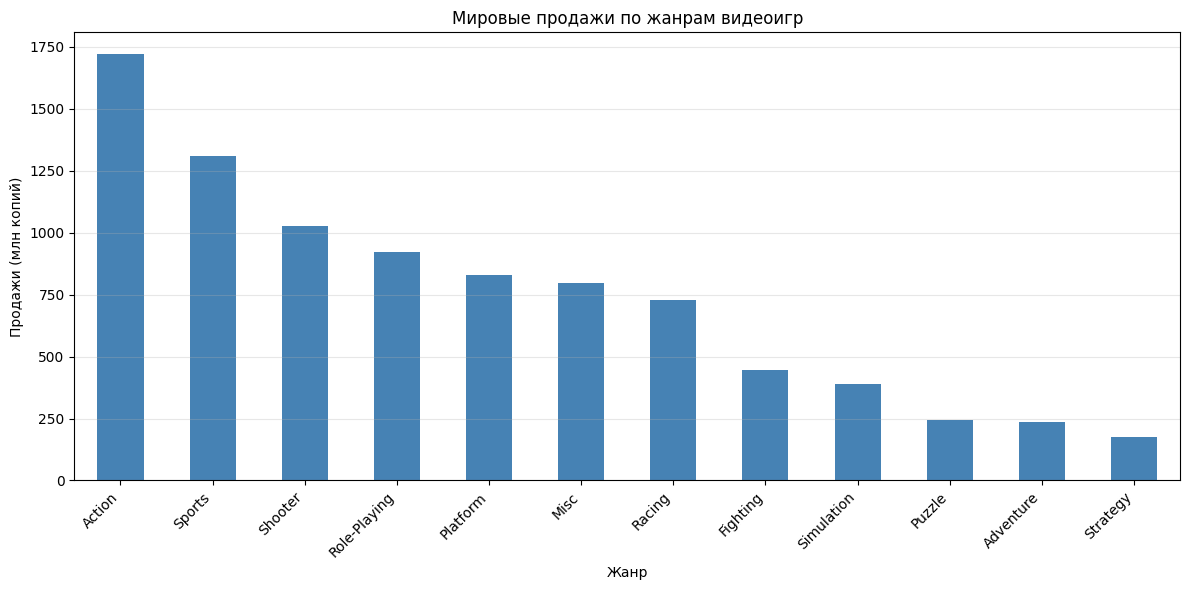

In [13]:
plt.figure(figsize=(12, 6))
genre_sales_sorted.plot(kind='bar', color='steelblue')
plt.title('Мировые продажи по жанрам видеоигр')
plt.xlabel('Жанр')
plt.ylabel('Продажи (млн копий)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Задание 11: Корреляция продаж

In [15]:
correlation = df_clean[["NA_Sales", "Global_Sales"]].corr()
print("Корреляционная матрица:")
print(correlation)

corr_value = correlation.loc["NA_Sales", "Global_Sales"]
print(f"\nКоэффициент корреляции между NA_Sales и Global_Sales: {corr_value:.4f}")

Корреляционная матрица:
              NA_Sales  Global_Sales
NA_Sales      1.000000      0.941268
Global_Sales  0.941268      1.000000

Коэффициент корреляции между NA_Sales и Global_Sales: 0.9413


Задание 12: Диаграмма рассеяния

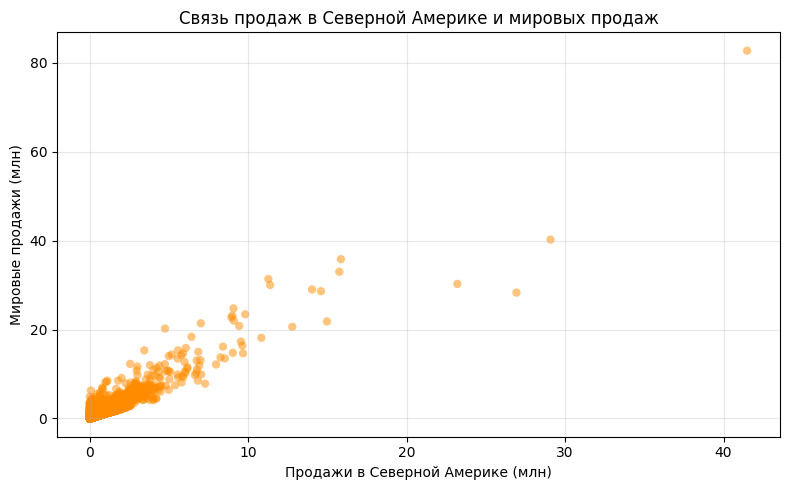

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_clean["NA_Sales"],
    df_clean["Global_Sales"],
    alpha=0.5,
    color='darkorange',
    edgecolors='none'
)
plt.title('Связь продаж в Северной Америке и мировых продаж')
plt.xlabel('Продажи в Северной Америке (млн)')
plt.ylabel('Мировые продажи (млн)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Задание 13: Корреляция между регионами

Корреляционная матрица региональных продаж:
             NA_Sales  EU_Sales  JP_Sales  Other_Sales
NA_Sales     1.000000  0.768936  0.451285     0.634508
EU_Sales     0.768936  1.000000  0.436414     0.726266
JP_Sales     0.451285  0.436414  1.000000     0.290653
Other_Sales  0.634508  0.726266  0.290653     1.000000


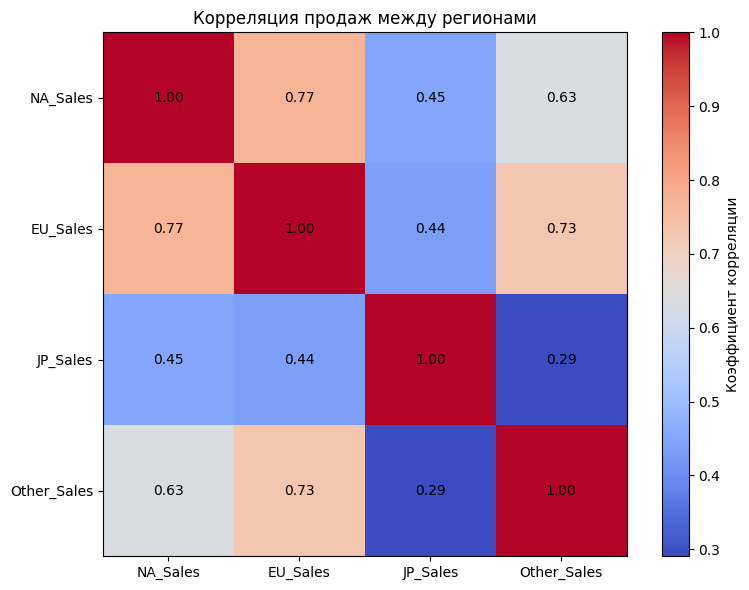

In [17]:
regional_corr = df_clean[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].corr()
print("Корреляционная матрица региональных продаж:")
print(regional_corr)

# Визуализация тепловой карты
plt.figure(figsize=(8, 6))
plt.imshow(regional_corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Коэффициент корреляции')
plt.xticks(range(len(regional_corr.columns)), regional_corr.columns)
plt.yticks(range(len(regional_corr.columns)), regional_corr.columns)
plt.title('Корреляция продаж между регионами')

# Добавление значений на график
for i in range(len(regional_corr.columns)):
    for j in range(len(regional_corr.columns)):
        plt.text(j, i, f'{regional_corr.iloc[i, j]:.2f}',
                 ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

Вопросы которые были на задниях
--------------------
Задания 2
определите:
какие столбцы являются числовыми?
какие столбцы являются текстовыми?
какие столбцы содержат данные о продажах?

Числовые
Rank (int64)
Year (float64 из-за наличия пропусков)
NA_Sales (float64)
EU_Sales (float64)
JP_Sales (float64)
Other_Sales (float64)
Global_Sales (float64)
Текстовые
Name (object)
Platform (object)
Genre (object)
Publisher (object)
Столбцы с данными о продажах
NA_Sales продажи в Северной Америке
EU_Sales  продажи в Европе
JP_Sales продажи в Японии
Other_Sales  продажи в остальных регионах
Global_Sales  мировые продажи
-----------------------------------
Задание 4
●	сколько строк было в исходном датасете?
●	сколько строк осталось после удаления пропусков Year?
●	почему, по вашему мнению, пропуски в Year могут мешать анализу игр по годам?

Строк в исходном датасете 16 598
Строк осталось после удаления пропусков Year 16 327
Удалено строк: 271

Почему пропуски в Year мешают анализу
Нельзя корректно группировать игры по годам (groupby("Year"))
Нельзя строить временные ряды и графики динамики продаж
Нельзя анализировать тренды по десятилетиям

------------------------------------
Задание 5
●	сколько жанров представлено?
●	сколько платформ?
●	сколько издателей?
●	какой из этих признаков имеет больше всего уникальных значений?

Жанров: 12
Платформ: 31
Издателей: 576
Больше всего уникальных значений признак Publisher (576 уникальных значений)

---------------------------------
Задание 10
●	какие жанры имеют наибольшие продажи?
●	какие жанры имеют наименьшие продажи?
●	насколько сильно отличаются значения?
Наибольшие продажи: Action (примерно 1745 млн), Sports (примерно 1332 млн), Shooter (премерно 1036 млн)
Наименьшие продажи: Strategy (примерно 175 млн), Puzzle (примено245 млн), Adventure (пррмео 239 млн)
Разница: Лидер (Action) превосходит аутсайдера (Strategy) примерно в 10 раз. Это очень существенное отличие  показывающее что жанровые предпочтения игроков сильно смещены в сторону экшена и спорта
------------------
Задание 11
●	получилось положительное или отрицательное значение?
●	близко ли оно к 1?
●	можно ли говорить о выраженной положительной взаимосвязи между NA_Sales и Global_Sales?

Значение  положительное

Коэффициент корреляции примерно 0.94

Близко ли к 1? Да очень близко

Да  можно говорить о сильной положительной линейной взаимосвязи. Это логично Северная Америка  крупнейший рынок, поэтому её продажи сильно влияют на мировые

-------------------------
Задание 12

●	что обозначает одна точка на графике?
●	наблюдается ли восходящая тенденция?
●	соответствует ли график результату корреляционного анализа?

 одна конкретная видеоигра из датасета

да, точки вытянуты вдоль восходящей линии

да, график полностью подтверждает высокую положительную корреляцию r примерно  0.94

----------------------
Задания 13
Какие региональные продажи сильнее всего связаны между собой?

Североамериканский и европейский рынки умеренно связаны между собой  игры, популярные в США, часто популярны и в Европе. Однако японский рынок JP_Sales практически не коррелирует с остальными r < 0.1, так что говорит о его уникальности и обособленности японские игроки имеют совершенно другие предпочтения и успех игры в Японии не означает её успеха на Западе


В ходе работы освоены навыки очистки и анализа данных с помощью Pandas и  NumPy и Matplotlib

Основные результаты

Обнаружены пропуски в Year (271) и Publisher (58) и  после очистки осталось 16 327 записей

В датасете 12 жанров и 31 платформа и  576 издателей

Лидер по продажам  жанр Action, по платформам  PS2.

Корреляция NA_Sales и Global_Sales очень высокая r примерно 0.94, а японский рынок практически не связан с остальными r < 0.1

Итог  данные очищены, закономерности выявлены, взаимосвязи подтверждены визуально. Навыки группировки, корреляционного анализа и визуализации успешно закреплены